In [1]:
import pandas as pd
import glob, os, json
import matplotlib.pyplot as plt

BASE_DIR = "../raw_csv/type4_thickness_vs_Vbr"
OUT_DIR  = "../results"
PLOT_DIR = "../results/plots"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

files = glob.glob(os.path.join(BASE_DIR, "*.csv"))
print("Found files:", files)
if not files:
    raise RuntimeError("No CSV files found in type4 folder")

Found files: ['../raw_csv/type4_thickness_vs_Vbr\\PolyTPD_Au_thickness_Vbr.csv', '../raw_csv/type4_thickness_vs_Vbr\\PTAA_Au_thickness_Vbr.csv']


In [2]:
rows = []

for f in files:
    df = pd.read_csv(f)
    df.columns = [c.strip() for c in df.columns]

    # rename Vrb -> Vbr if needed
    if "Vrb" in df.columns and "Vbr" not in df.columns:
        df = df.rename(columns={"Vrb": "Vbr"})

    if "Vbr" not in df.columns or "thickness" not in df.columns:
        raise RuntimeError(f"Expected columns not found in {os.path.basename(f)}")

    fname = os.path.basename(f)

    if "PTAA" in fname:
        df["HTL"] = "PTAA"
    elif "Poly" in fname or "PolyTPD" in fname or "Poly-TPD" in fname:
        df["HTL"] = "Poly-TPD"
    else:
        df["HTL"] = "Unknown"

    if "Au" in fname:
        df["Electrode"] = "Au"
    elif "Ag" in fname:
        df["Electrode"] = "Ag"
    else:
        df["Electrode"] = "Unknown"

    df["SourceFile"] = fname
    rows.append(df)

type4_df = pd.concat(rows, ignore_index=True)
print(type4_df.head())


     Vbr thickness       HTL Electrode                    SourceFile
0  -8.80     16 nm  Poly-TPD        Au  PolyTPD_Au_thickness_Vbr.csv
1  -5.55     16 nm  Poly-TPD        Au  PolyTPD_Au_thickness_Vbr.csv
2  -5.87     16 nm  Poly-TPD        Au  PolyTPD_Au_thickness_Vbr.csv
3 -11.42     16 nm  Poly-TPD        Au  PolyTPD_Au_thickness_Vbr.csv
4  -8.01     16 nm  Poly-TPD        Au  PolyTPD_Au_thickness_Vbr.csv


In [3]:
# clean thickness: "18 nm" -> 18
type4_df["thickness_nm"] = (
    type4_df["thickness"]
    .astype(str)
    .str.replace("nm", "", case=False)
    .str.strip()
    .astype(float)
)

# numeric Vbr
type4_df["Vbr"] = pd.to_numeric(type4_df["Vbr"], errors="coerce")

type4_df = type4_df.dropna(subset=["Vbr", "thickness_nm"])

# PerovAI tags
type4_df["Type"] = "Type4"
type4_df["Week"] = 8
type4_df["DatasetRole"] = "Scaling"

print(type4_df.head())

     Vbr thickness       HTL Electrode                    SourceFile  \
0  -8.80     16 nm  Poly-TPD        Au  PolyTPD_Au_thickness_Vbr.csv   
1  -5.55     16 nm  Poly-TPD        Au  PolyTPD_Au_thickness_Vbr.csv   
2  -5.87     16 nm  Poly-TPD        Au  PolyTPD_Au_thickness_Vbr.csv   
3 -11.42     16 nm  Poly-TPD        Au  PolyTPD_Au_thickness_Vbr.csv   
4  -8.01     16 nm  Poly-TPD        Au  PolyTPD_Au_thickness_Vbr.csv   

   thickness_nm   Type  Week DatasetRole  
0          16.0  Type4     8     Scaling  
1          16.0  Type4     8     Scaling  
2          16.0  Type4     8     Scaling  
3          16.0  Type4     8     Scaling  
4          16.0  Type4     8     Scaling  


In [4]:
out_csv = os.path.join(OUT_DIR, "perovai_type4_thickness_week08.csv")
type4_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

meta = {
    "dataset": "perovai_type4_thickness_week08",
    "description": "Breakdown voltage vs HTL thickness (scaling), Week08",
    "week": 8,
    "type": "Type4",
    "columns": type4_df.columns.tolist(),
    "HTLs": sorted(type4_df["HTL"].unique().tolist()),
    "electrodes": sorted(type4_df["Electrode"].unique().tolist()),
    "thickness_nm": sorted(type4_df["thickness_nm"].unique().tolist()),
    "source_files": sorted(type4_df["SourceFile"].unique().tolist()),
    "units": {"Vbr": "V", "thickness_nm": "nm"}
}

with open(os.path.join(OUT_DIR, "perovai_type4_thickness_week08_metadata.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("Saved metadata")

Saved: ../results\perovai_type4_thickness_week08.csv
Saved metadata


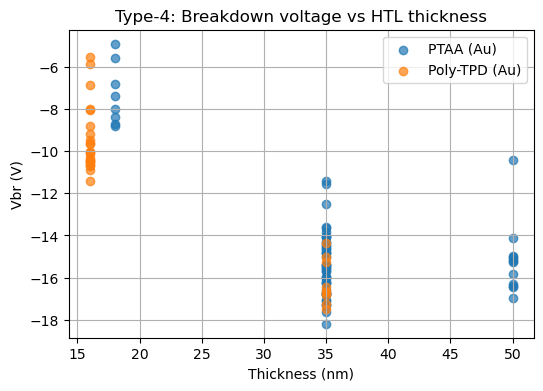

In [5]:
fig = plt.figure(figsize=(6,4))

for (htl, elec), g in type4_df.groupby(["HTL","Electrode"]):
    plt.scatter(g["thickness_nm"], g["Vbr"], label=f"{htl} ({elec})", alpha=0.7)

plt.xlabel("Thickness (nm)")
plt.ylabel("Vbr (V)")
plt.title("Type‑4: Breakdown voltage vs HTL thickness")
plt.legend()
plt.grid(True)

fig.savefig(os.path.join(PLOT_DIR, "type4_vbr_vs_thickness.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(PLOT_DIR, "type4_vbr_vs_thickness.pdf"), bbox_inches="tight")
plt.show()

C:\Users\Mazhar\AppData\Local\Temp\ipykernel_15380\1379788505.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels)


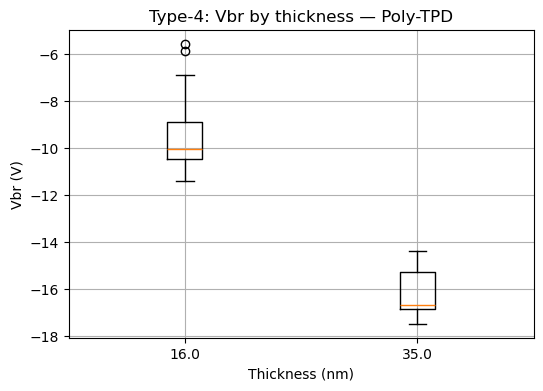

C:\Users\Mazhar\AppData\Local\Temp\ipykernel_15380\1379788505.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels)


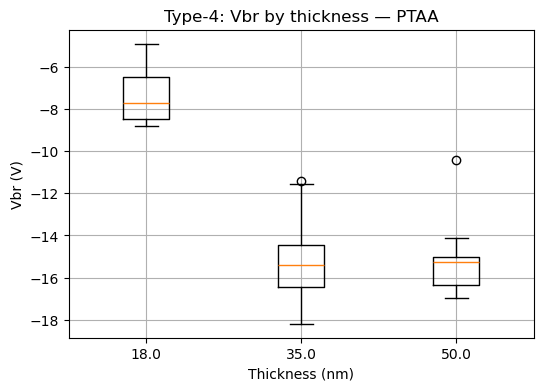

In [6]:
for htl in type4_df["HTL"].unique():
    sub = type4_df[type4_df["HTL"] == htl]

    fig, ax = plt.subplots(figsize=(6,4))
    groups = [g["Vbr"].values for _, g in sub.groupby("thickness_nm")]
    labels = [str(k) for k in sorted(sub["thickness_nm"].unique())]

    ax.boxplot(groups, labels=labels)
    ax.set_xlabel("Thickness (nm)")
    ax.set_ylabel("Vbr (V)")
    ax.set_title(f"Type‑4: Vbr by thickness — {htl}")
    ax.grid(True)

    fig.savefig(os.path.join(PLOT_DIR, f"type4_vbr_box_by_thickness_{htl}.png"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(PLOT_DIR, f"type4_vbr_box_by_thickness_{htl}.pdf"), bbox_inches="tight")
    plt.show()